# 04 · Automatic vs manual annotations, and the model

The collaborator drew lesion **cores** (not rims), grey/white matter and vessel (VBO) regions. They
were used for two things only: training the lesion model (leave-one-scene-out) and validation.
This notebook shows where the two agree and, more importantly, where they do not – so you can decide
which one is right in each case.

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


## Model: leave-one-scene-out training report

In [2]:
rep = Path("models/training_report.csv")
display(pd.read_csv(rep).round(3) if rep.exists() else "no model report")
import joblib
m = joblib.load(runs[0].log["lesion_model"]["path"]) if "lesion_model" in runs[0].log else None
print("features:", m["features"] if m else "–")

,held_out,auc,avg_precision,n_cores,cores_detected_frac
0,CML_1_scene0,0.996,0.923,34,0.794
1,CML_2_rescan_scene0,0.995,0.903,25,0.920
2,CML_metal_scene0,0.996,0.839,33,0.818
3,CML_metal_scene1,0.995,0.679,20,0.950


features: ['nuc_20', 'pu1_20', 'frac_20', 'nuc_40', 'pu1_40', 'frac_40', 'z_nuc', 'z_pu1', 'z_frac', 'nuc_80', 'pu1_80', 'frac_80', 'pu1_int_pos40', 'pu1_int_all40', 'iba1_int_pos40', 'iba1_int_all40', 'rel_pos', 'dist_edge_rel', 'dist_edge_um']


Bin-level AUC is near 1 because most tissue is trivially negative; `avg_precision` and
`cores_detected_frac` (manual cores ≥50 % inside the automatic lesion) are the informative columns.

## Threshold baseline for comparison

In [3]:
g = Path("outputs/lesion_threshold_grid.csv")
if g.exists():
    grid = pd.read_csv(g)
    display(grid.sort_values(["det_frac", "ctrl_area_mm2"], ascending=[False, True]).head(12).round(3))
    print("det_frac = manual cores detected; ctrl_area_mm2 = lesion area in CFA/OS control sections; excess_frac = automatic area in annotated sections outside manual core + 100 µm")

,low,seed,min_area_um2,det_frac,ctrl_area_mm2,excess_frac,lesion_area_annot_mm2,n_lesions,n_les_annot
10,3.0,NaN,5000,0.955,0.140,0.38,10.43,190,138
0,2.5,NaN,5000,0.955,0.206,0.43,12.31,215,154
22,3.5,5.0,5000,0.946,0.087,0.32,9.00,149,111
12,3.0,5.0,5000,0.946,0.101,0.35,10.04,147,109
20,3.5,NaN,5000,0.946,0.107,0.33,9.13,168,123
2,2.5,5.0,5000,0.946,0.124,0.40,11.57,138,101
32,4.0,5.0,5000,0.938,0.074,0.29,8.01,146,109
30,4.0,NaN,5000,0.938,0.081,0.29,8.04,151,113
24,3.5,6.0,5000,0.938,0.087,0.31,8.86,131,96
14,3.0,6.0,5000,0.938,0.101,0.34,9.84,126,92


det_frac = manual cores detected; ctrl_area_mm2 = lesion area in CFA/OS control sections; excess_frac = automatic area in annotated sections outside manual core + 100 µm


## Agreement summary per scene

In [4]:
rows = []
for r in runs:
    v = r.log["validation"]; c = v["core_vs_lesion"]; k = v["core_vs_core"]
    rows.append({"scene": r.name, "manual cores": v["n_manual_cores"], "cores ≥50% inside auto lesion": v["manual_cores_detected_frac"],
                 "manual area inside auto lesion": c["manual_covered_by_auto"], "auto lesion mm²": c["auto_area_mm2"], "manual core mm²": c["manual_area_mm2"],
                 "IoU lesion vs core": c["iou"], "IoU auto core vs manual core": k["iou"]})
pd.DataFrame(rows).round(3)

,scene,manual cores,cores ≥50% inside auto lesion,manual area inside auto lesion,auto lesion mm²,manual core mm²,IoU lesion vs core,IoU auto core vs manual core
0,CML_1 scene 0,34,0.706,0.894,1.661,0.690,0.356,0.462
1,CML_2_rescan scene 0,25,0.840,0.849,1.533,0.972,0.492,0.417
2,CML_metal scene 0,33,0.636,0.849,1.062,0.439,0.330,0.388
3,CML_metal scene 1,20,0.900,0.901,1.458,0.364,0.220,0.326


## Per manual core: how much of it lies inside the automatic lesion

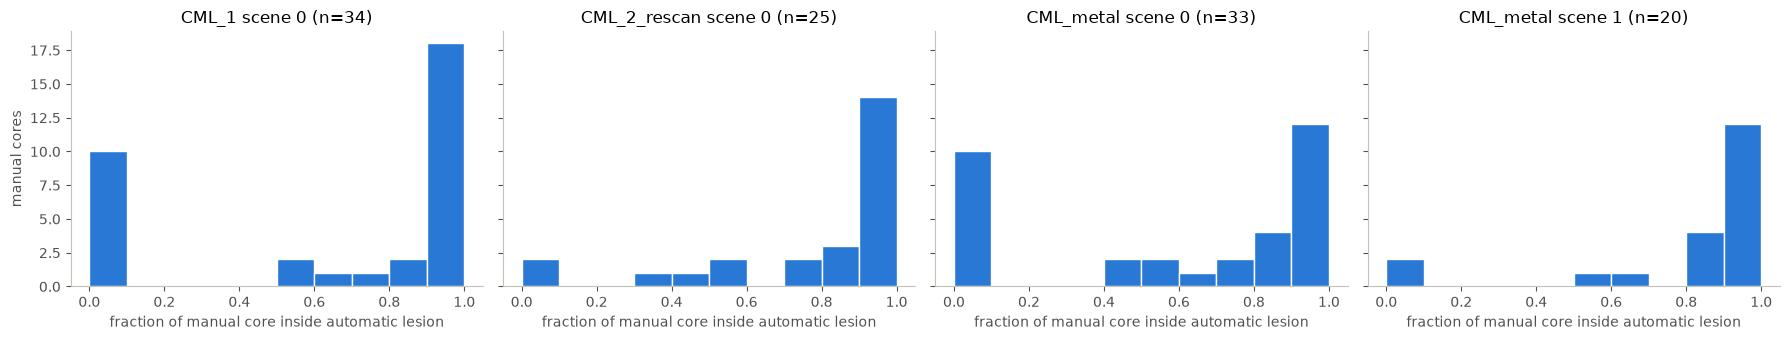

In [5]:
fig, axes = plt.subplots(1, len(runs), figsize=(4.5 * len(runs), 3.5), sharey=True, squeeze=False)
for ax, r in zip(axes.ravel(), runs):
    v = pd.read_csv(r.dir / "validation_manual_cores.csv")
    ax.hist(v.frac_in_auto_lesion, bins=np.linspace(0, 1, 11), color="#2a78d6", edgecolor="white")
    ax.set_title(f"{r.name} (n={len(v)})"); ax.set_xlabel("fraction of manual core inside automatic lesion")
axes[0, 0].set_ylabel("manual cores")
plt.tight_layout()

## Manual cores the automatic mask missed (< 50 % covered)

### CML_1 scene 0: 10 missed manual core(s)

,manual_core_id,area_um2,frac_in_auto_lesion,frac_core,frac_rim,frac_peri,frac_deep,frac_distal,auto_lesion_ids
7,8,1400.0,0.0,0.0,0.0,0.00,0.00,0.93,[]
10,11,3000.0,0.0,0.0,0.0,0.90,0.03,0.00,[]
11,12,3500.0,0.0,0.0,0.0,0.00,0.00,0.94,[]
12,13,1300.0,0.0,0.0,0.0,0.00,0.00,1.00,[]
13,14,4700.0,0.0,0.0,0.0,0.00,0.00,1.00,[]
14,15,700.0,0.0,0.0,0.0,0.00,0.00,1.00,[]
28,29,5300.0,0.0,0.0,0.0,0.06,0.89,0.00,[]
30,31,3800.0,0.0,0.0,0.0,0.00,0.00,1.00,[]
31,32,1800.0,0.0,0.0,0.0,0.00,0.00,1.00,[]
32,33,800.0,0.0,0.0,0.0,0.00,0.00,1.00,[]


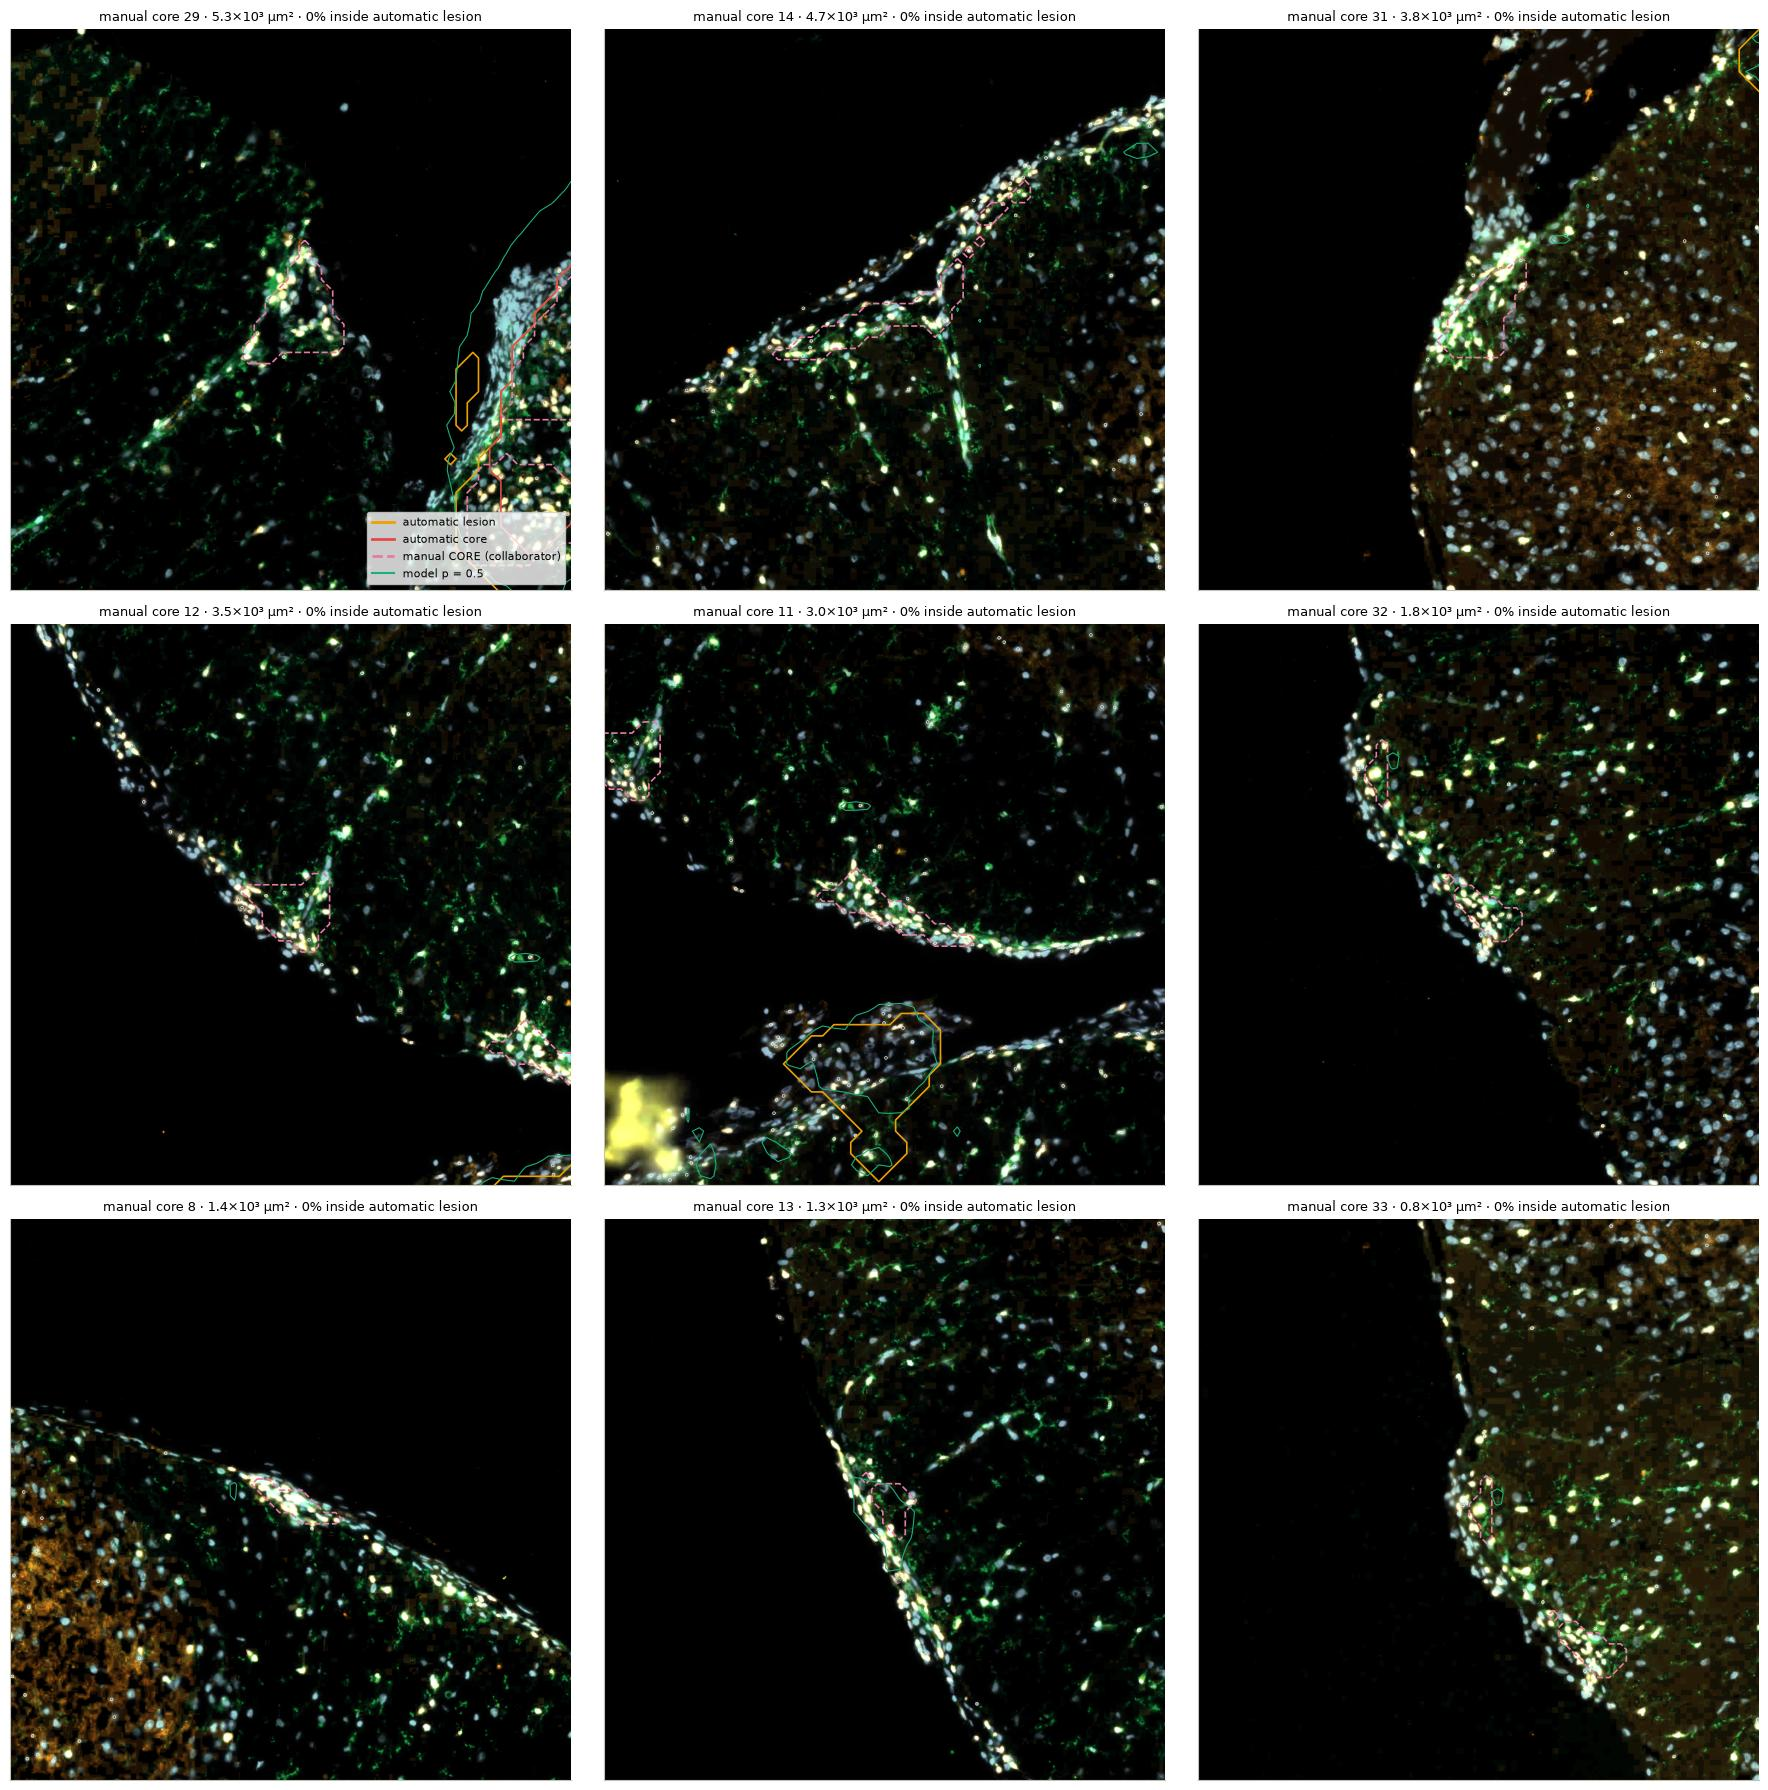

### CML_2_rescan scene 0: 4 missed manual core(s)

,manual_core_id,area_um2,frac_in_auto_lesion,frac_core,frac_rim,frac_peri,frac_deep,frac_distal,auto_lesion_ids
2,3,15100.0,0.07,0.00,0.07,0.93,0.00,0.0,[1]
8,9,33300.0,0.39,0.01,0.38,0.59,0.00,0.0,"[29, 30]"
19,20,19000.0,0.00,0.00,0.00,0.76,0.24,0.0,[]
23,24,12100.0,0.49,0.00,0.49,0.51,0.00,0.0,[17]


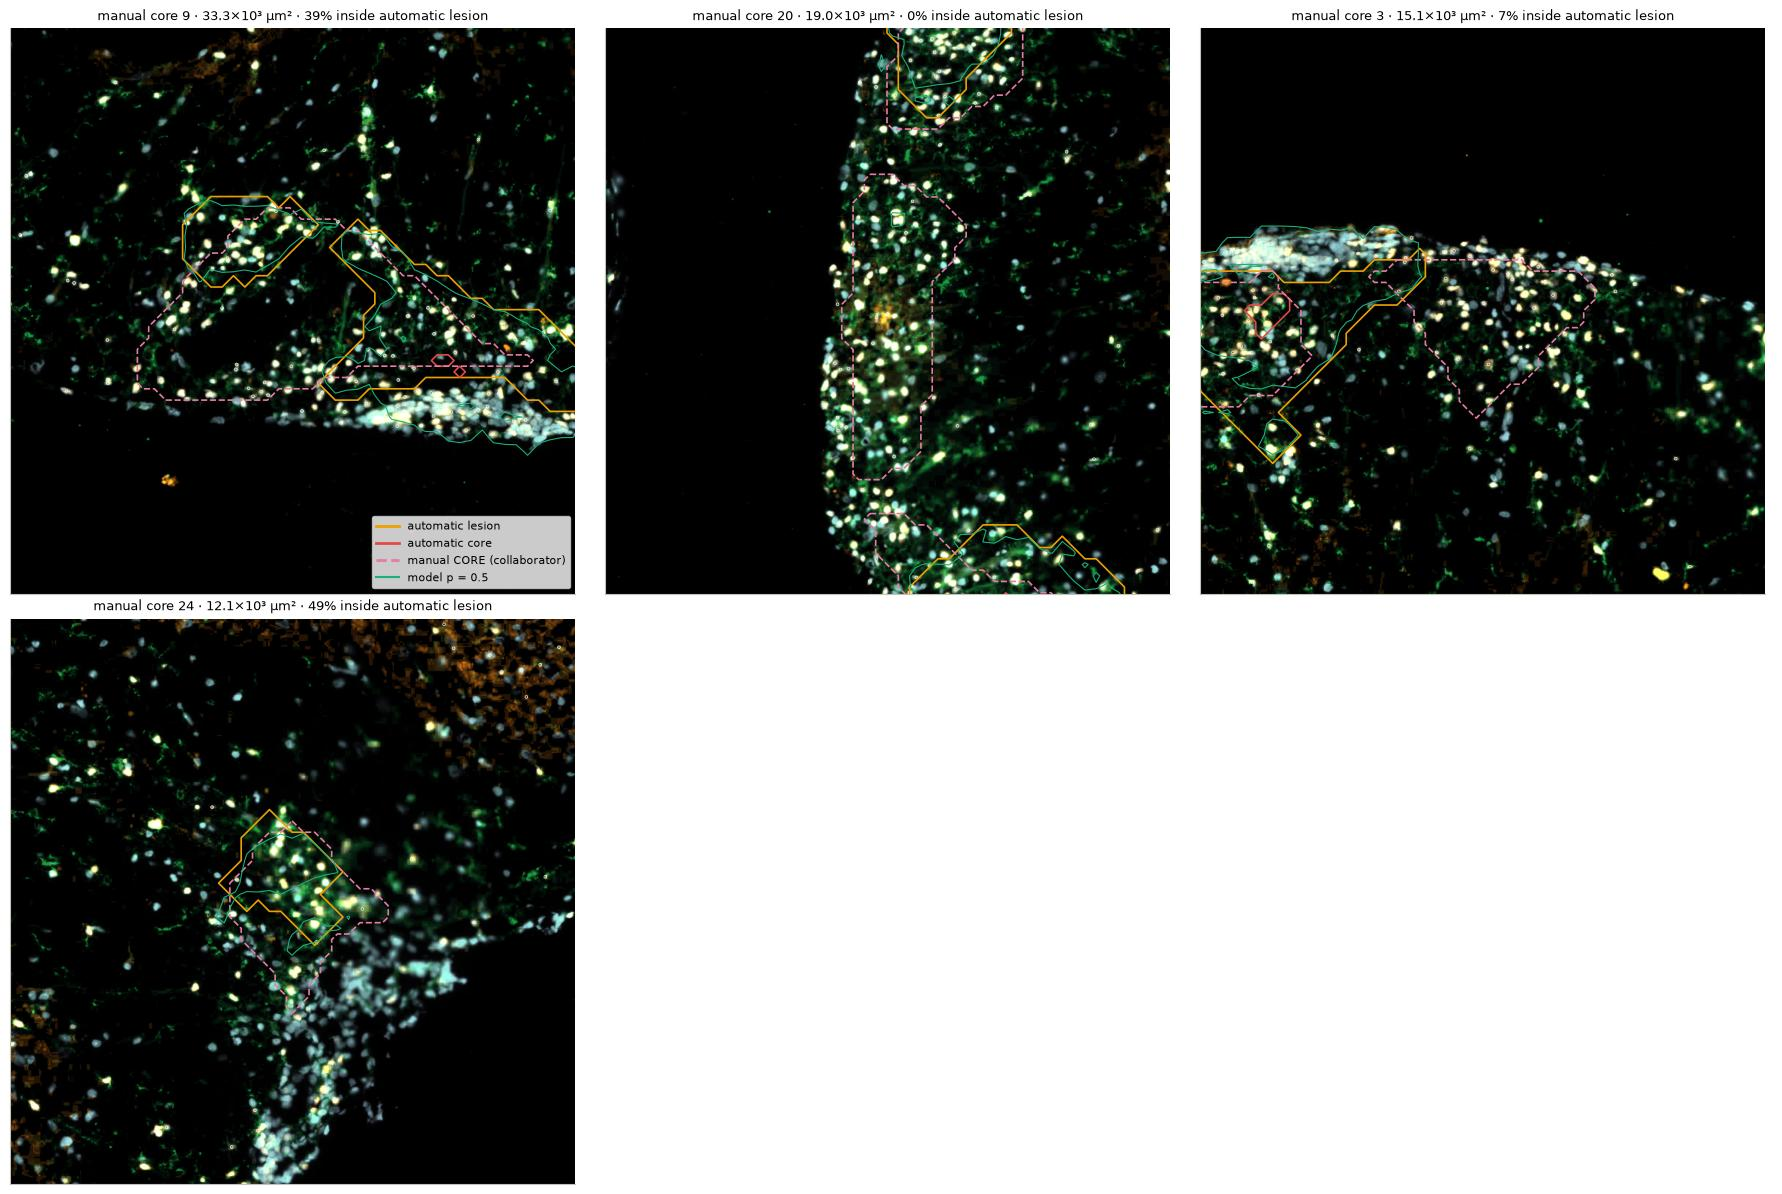

### CML_metal scene 0: 12 missed manual core(s)

,manual_core_id,area_um2,frac_in_auto_lesion,frac_core,frac_rim,frac_peri,frac_deep,frac_distal,auto_lesion_ids
0,1,3100.0,0.00,0.00,0.00,0.00,0.74,0.16,[]
1,2,1000.0,0.00,0.00,0.00,0.00,0.00,0.90,[]
2,3,600.0,0.00,0.00,0.00,0.00,0.00,1.00,[]
4,5,7700.0,0.47,0.00,0.47,0.53,0.00,0.00,[8]
5,6,1900.0,0.00,0.00,0.00,0.00,0.58,0.42,[]
6,7,3000.0,0.00,0.00,0.00,0.00,0.00,1.00,[]
7,8,1300.0,0.00,0.00,0.00,0.00,0.00,1.00,[]
12,13,1300.0,0.00,0.00,0.00,0.00,0.00,1.00,[]
18,19,16200.0,0.00,0.00,0.00,0.00,0.00,1.00,[]
19,20,1300.0,0.00,0.00,0.00,0.00,0.85,0.00,[]


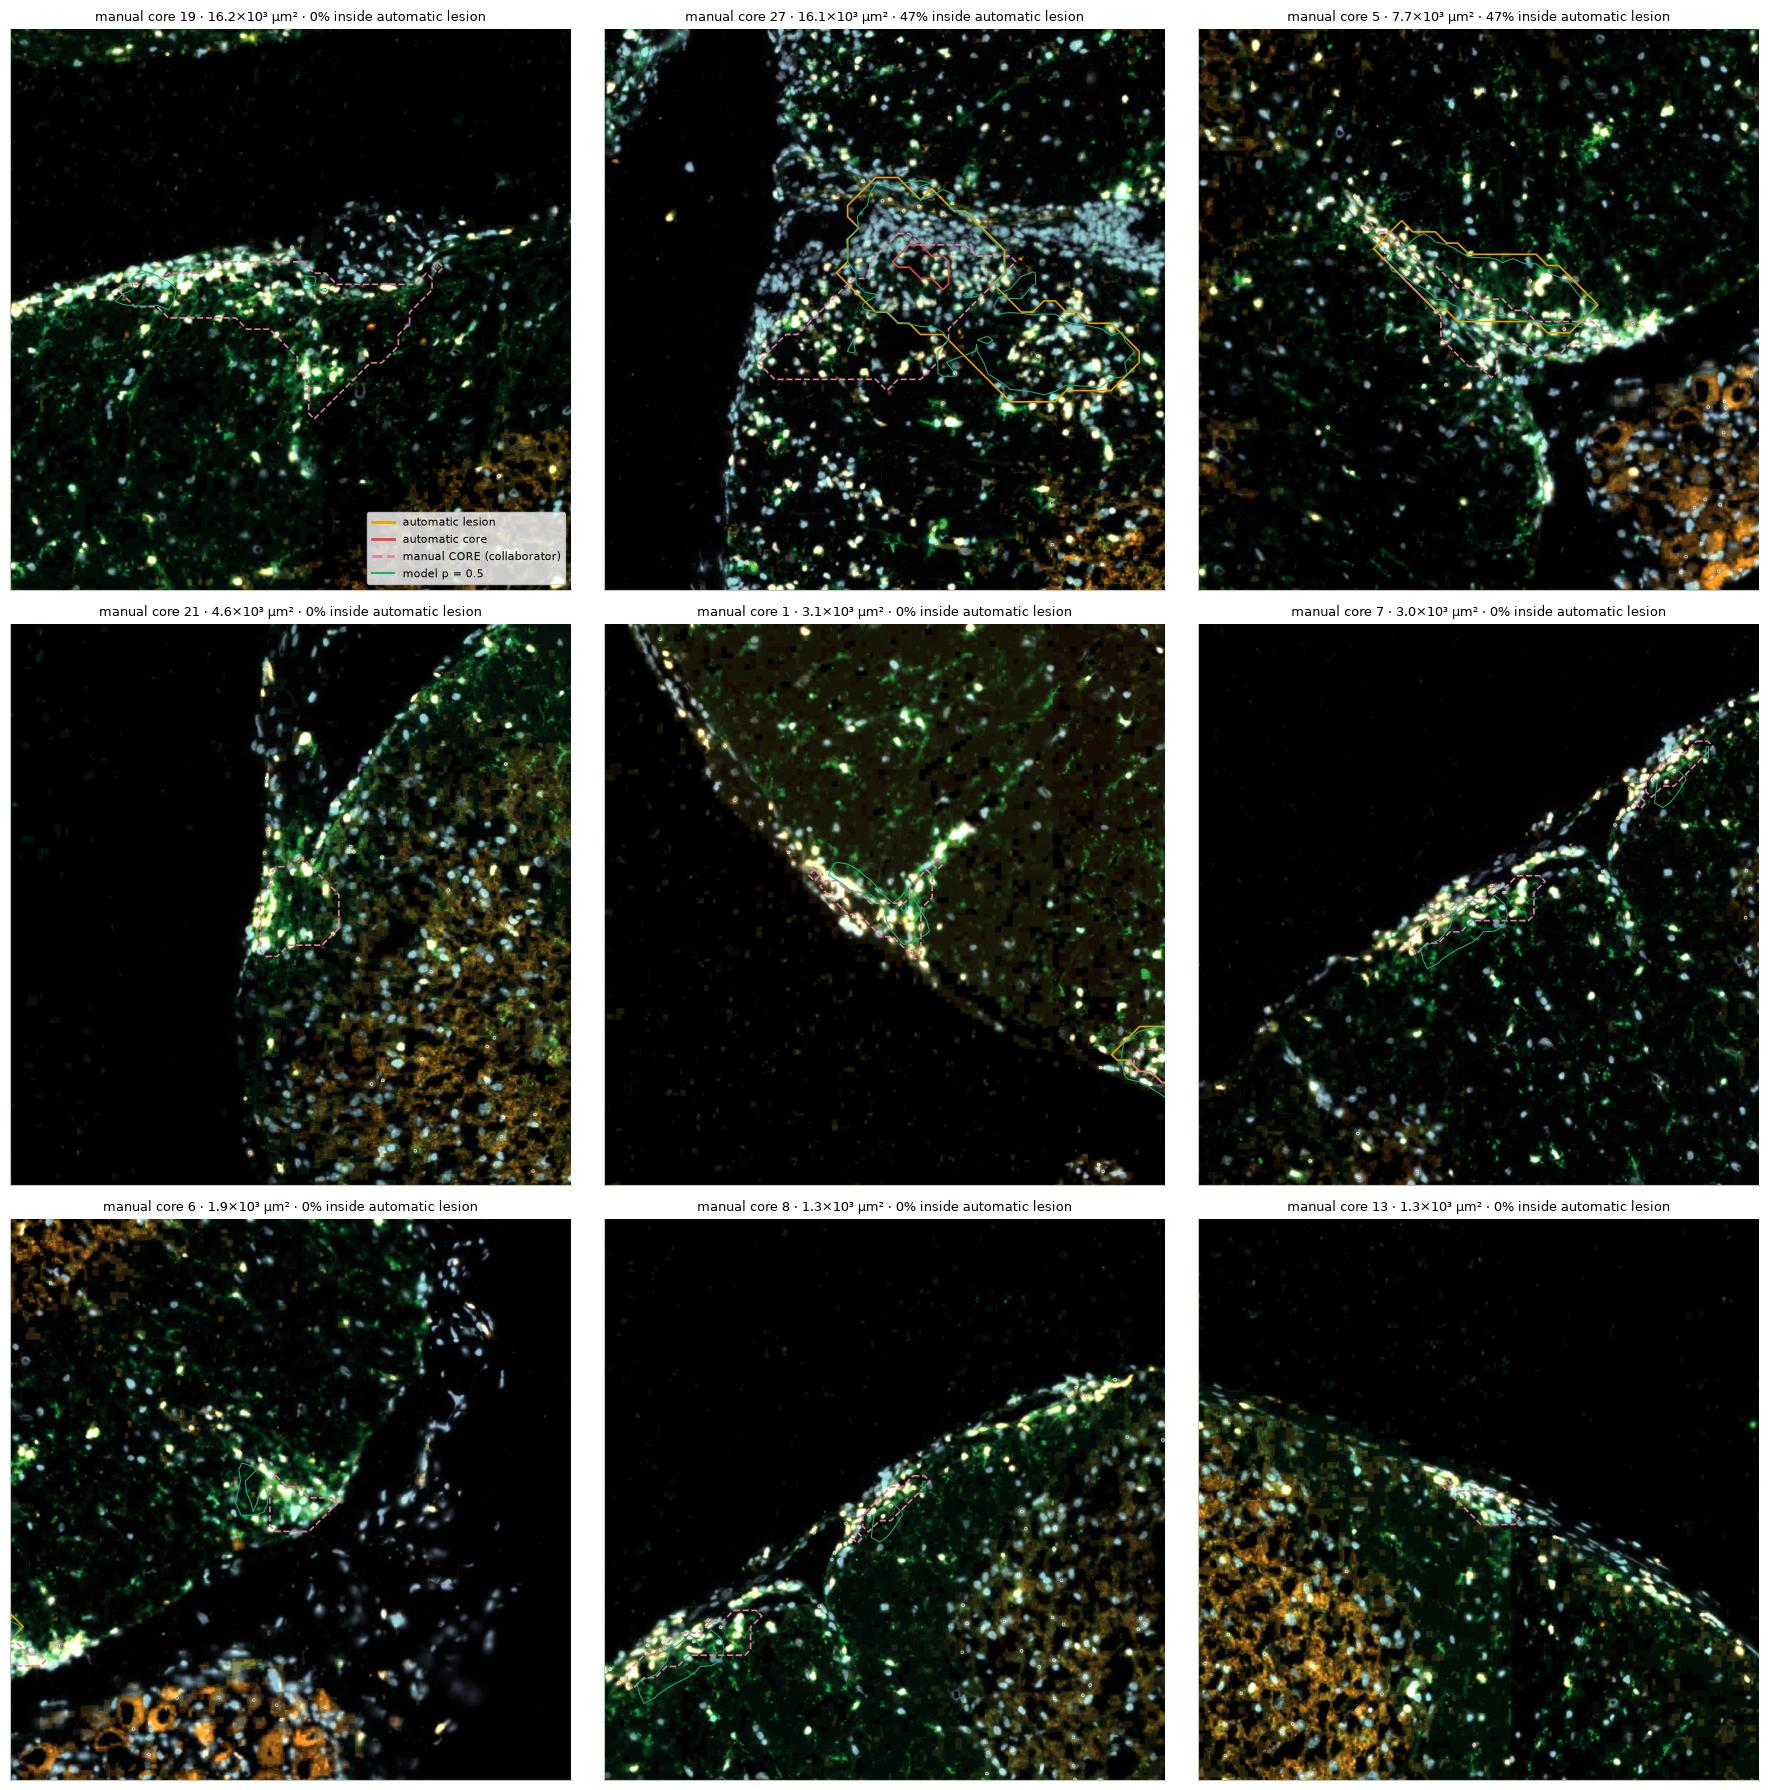

### CML_metal scene 1: 2 missed manual core(s)

,manual_core_id,area_um2,frac_in_auto_lesion,frac_core,frac_rim,frac_peri,frac_deep,frac_distal,auto_lesion_ids
10,11,8700.0,0.08,0.0,0.08,0.92,0.0,0.0,[1]
15,16,11800.0,0.00,0.0,0.00,0.00,0.0,1.0,[]


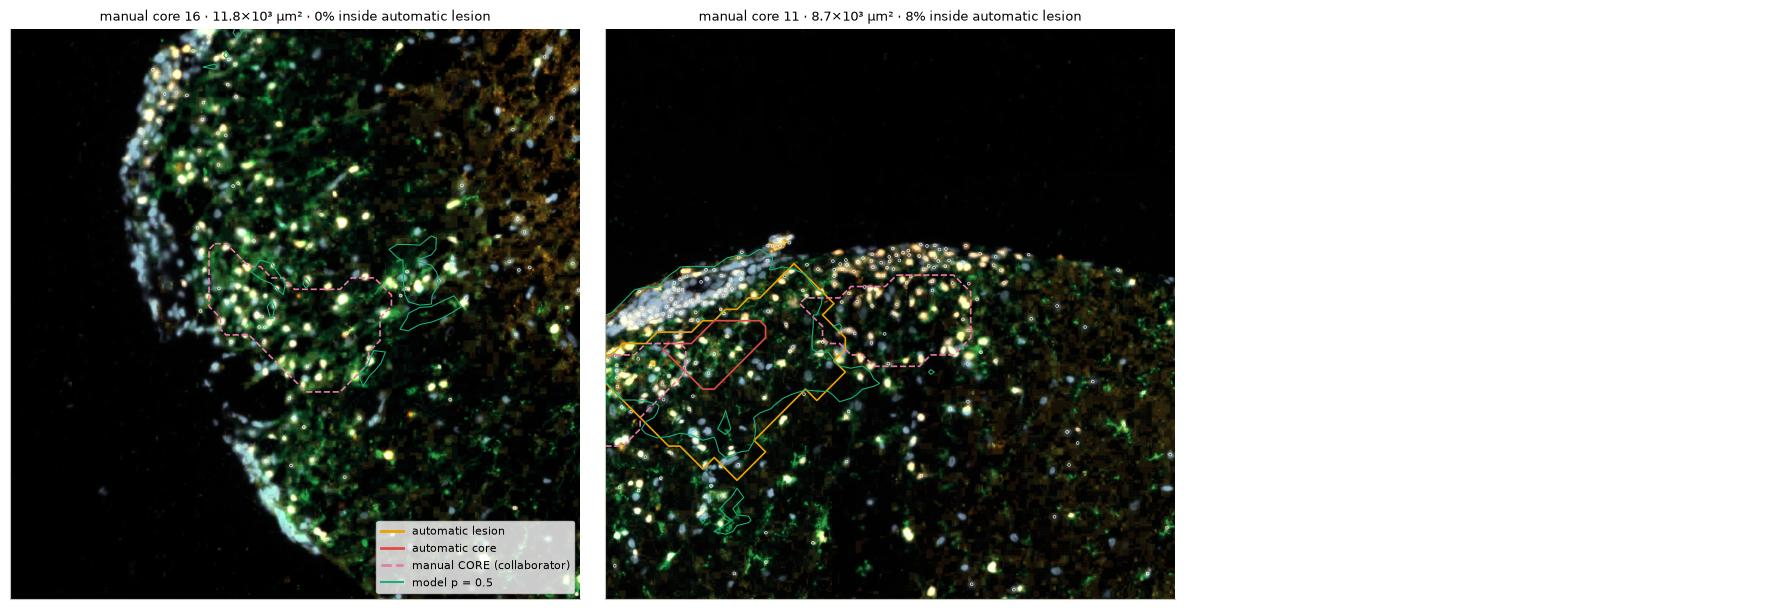

In [6]:
for r in runs:
    miss = R.missed_manual_cores(r)
    display(Markdown(f"### {r.name}: {len(miss)} missed manual core(s)"))
    if len(miss):
        display(miss.round(2))
        fig = R.manual_core_gallery(r, miss.sort_values("area_um2", ascending=False), max_n=9)
        plt.show()

## Automatic lesions with no manual core inside them

### CML_1 scene 0: 17 automatic lesion(s) without a manual core (0.13 mm²)

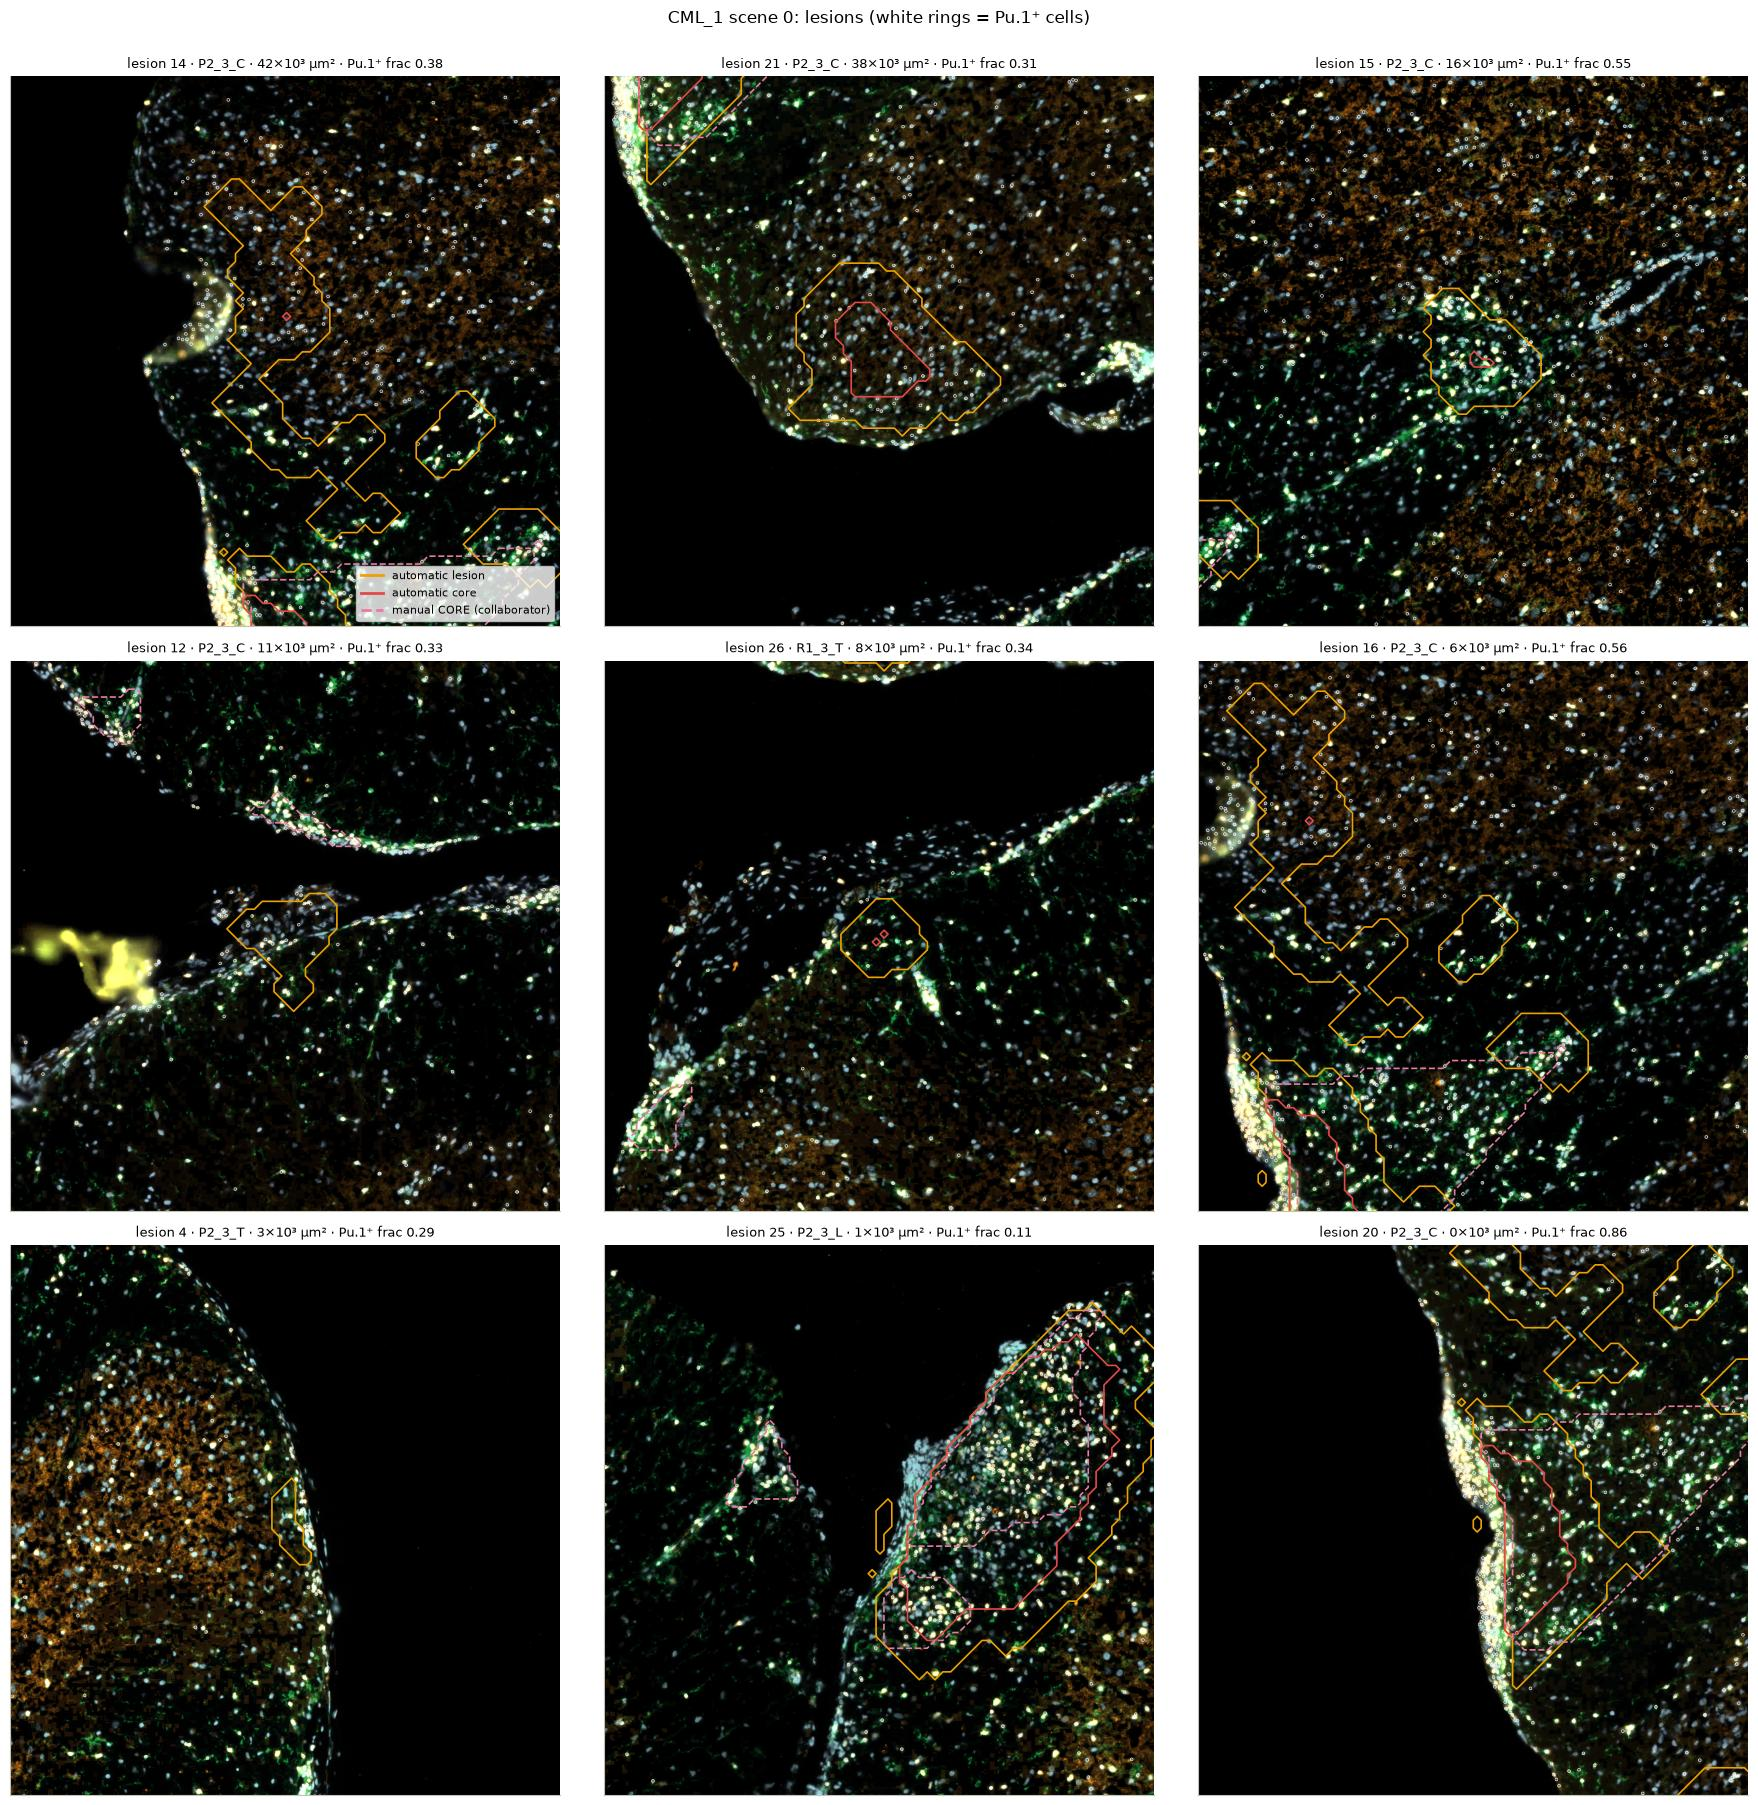

### CML_2_rescan scene 0: 17 automatic lesion(s) without a manual core (0.08 mm²)

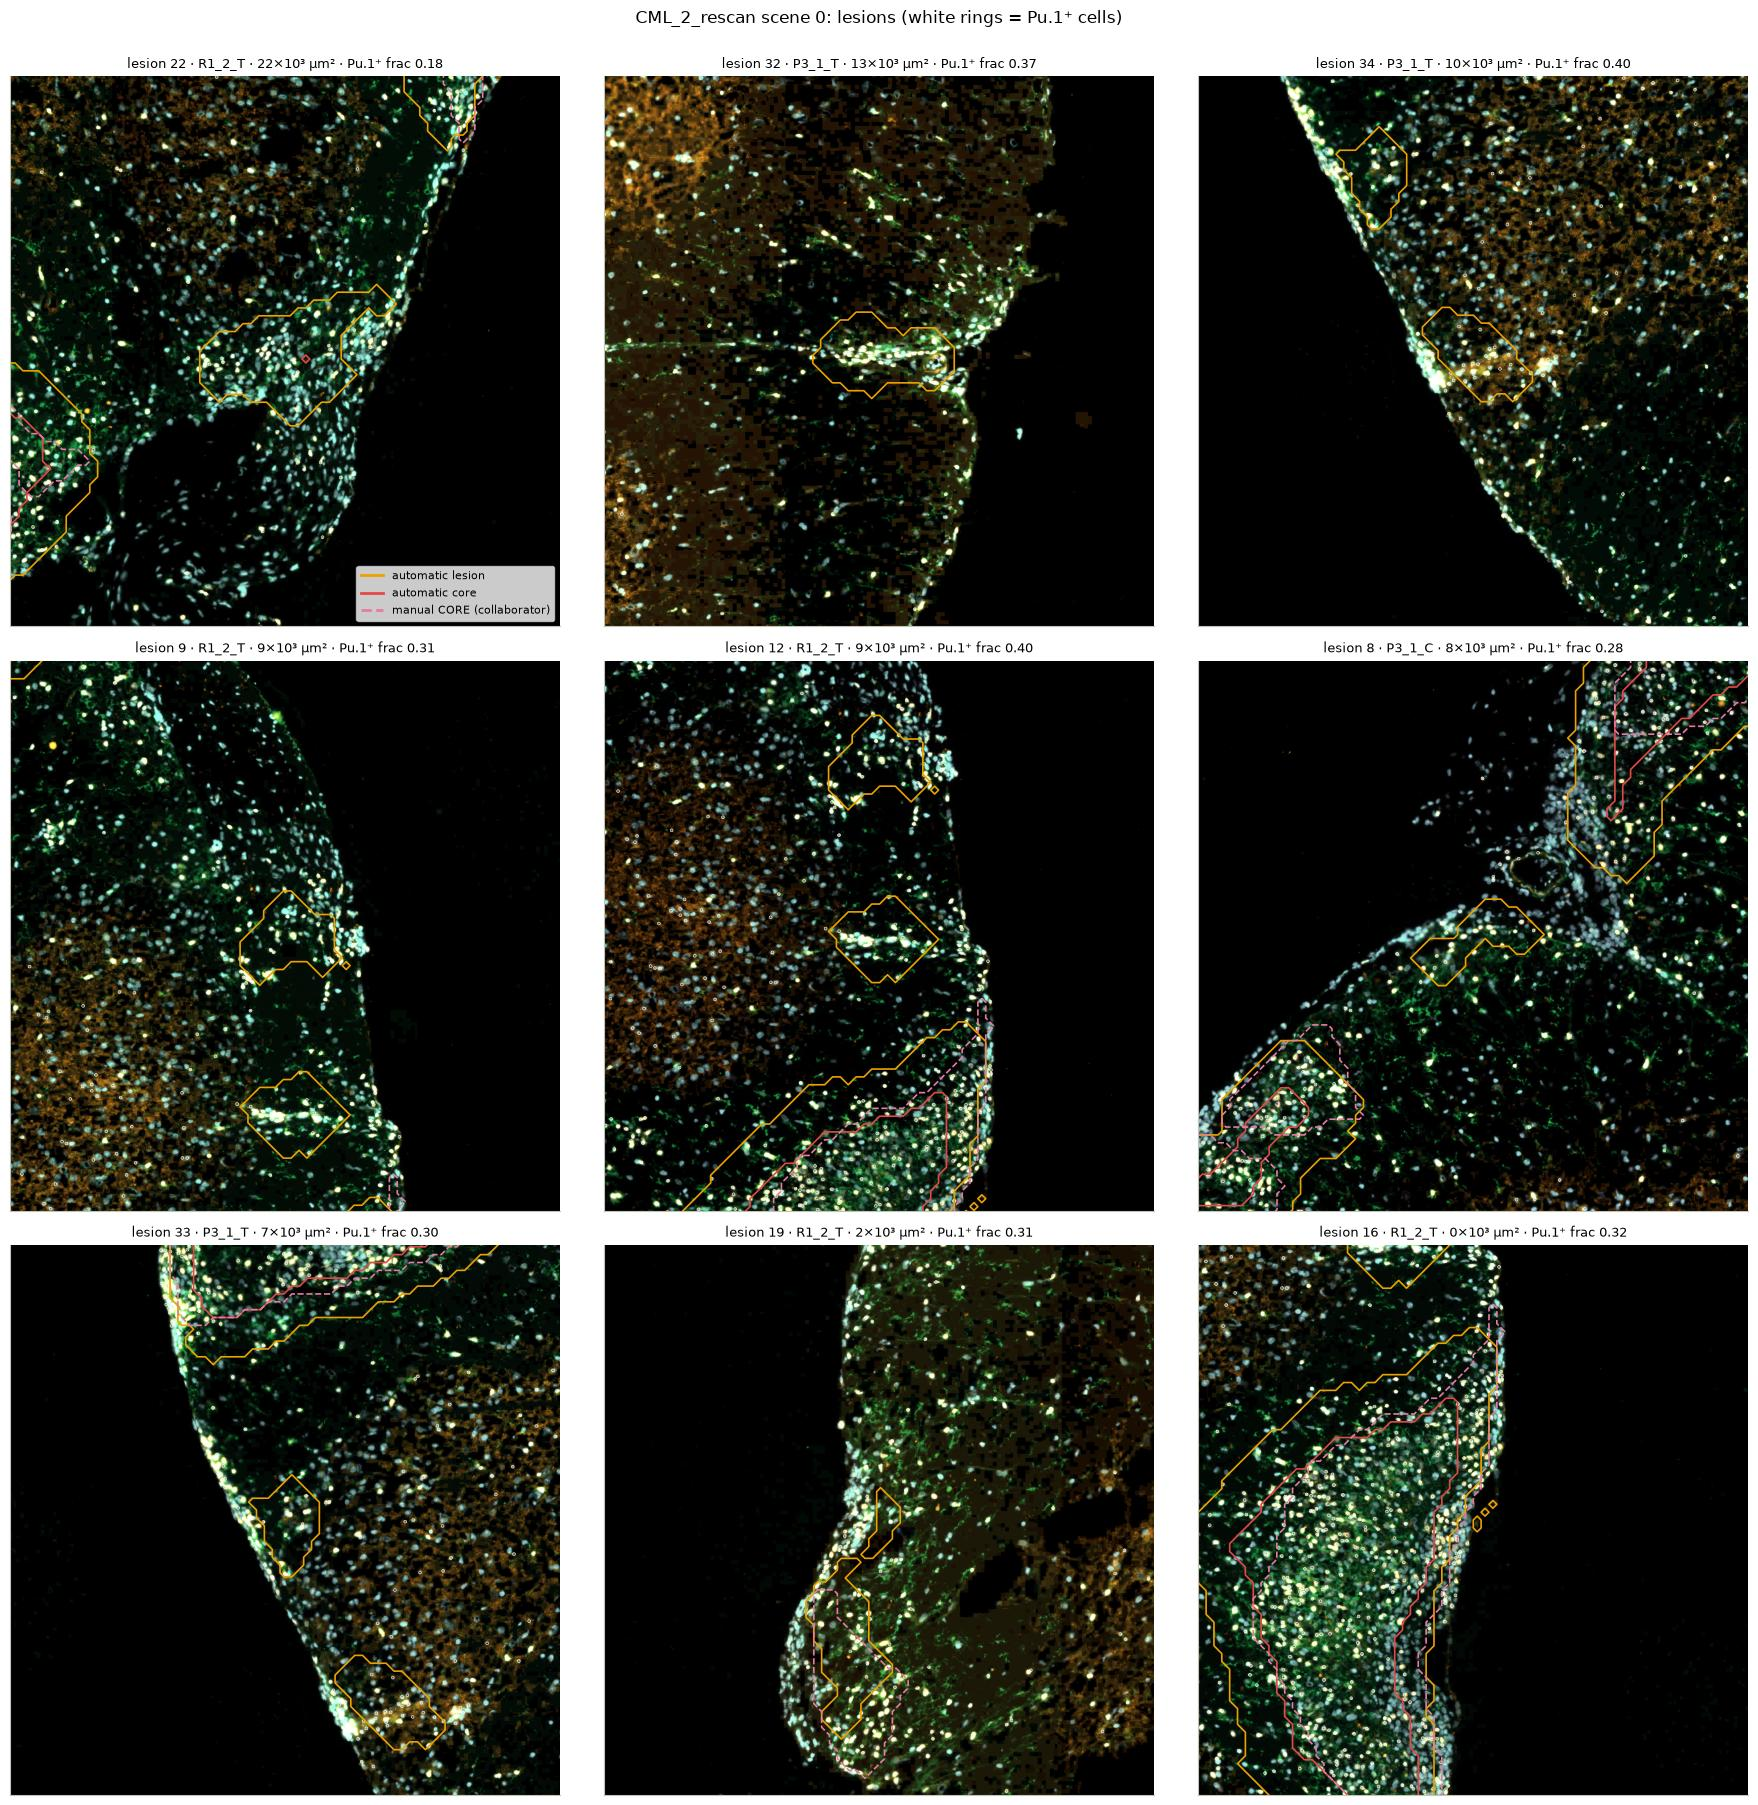

### CML_metal scene 0: 9 automatic lesion(s) without a manual core (0.13 mm²)

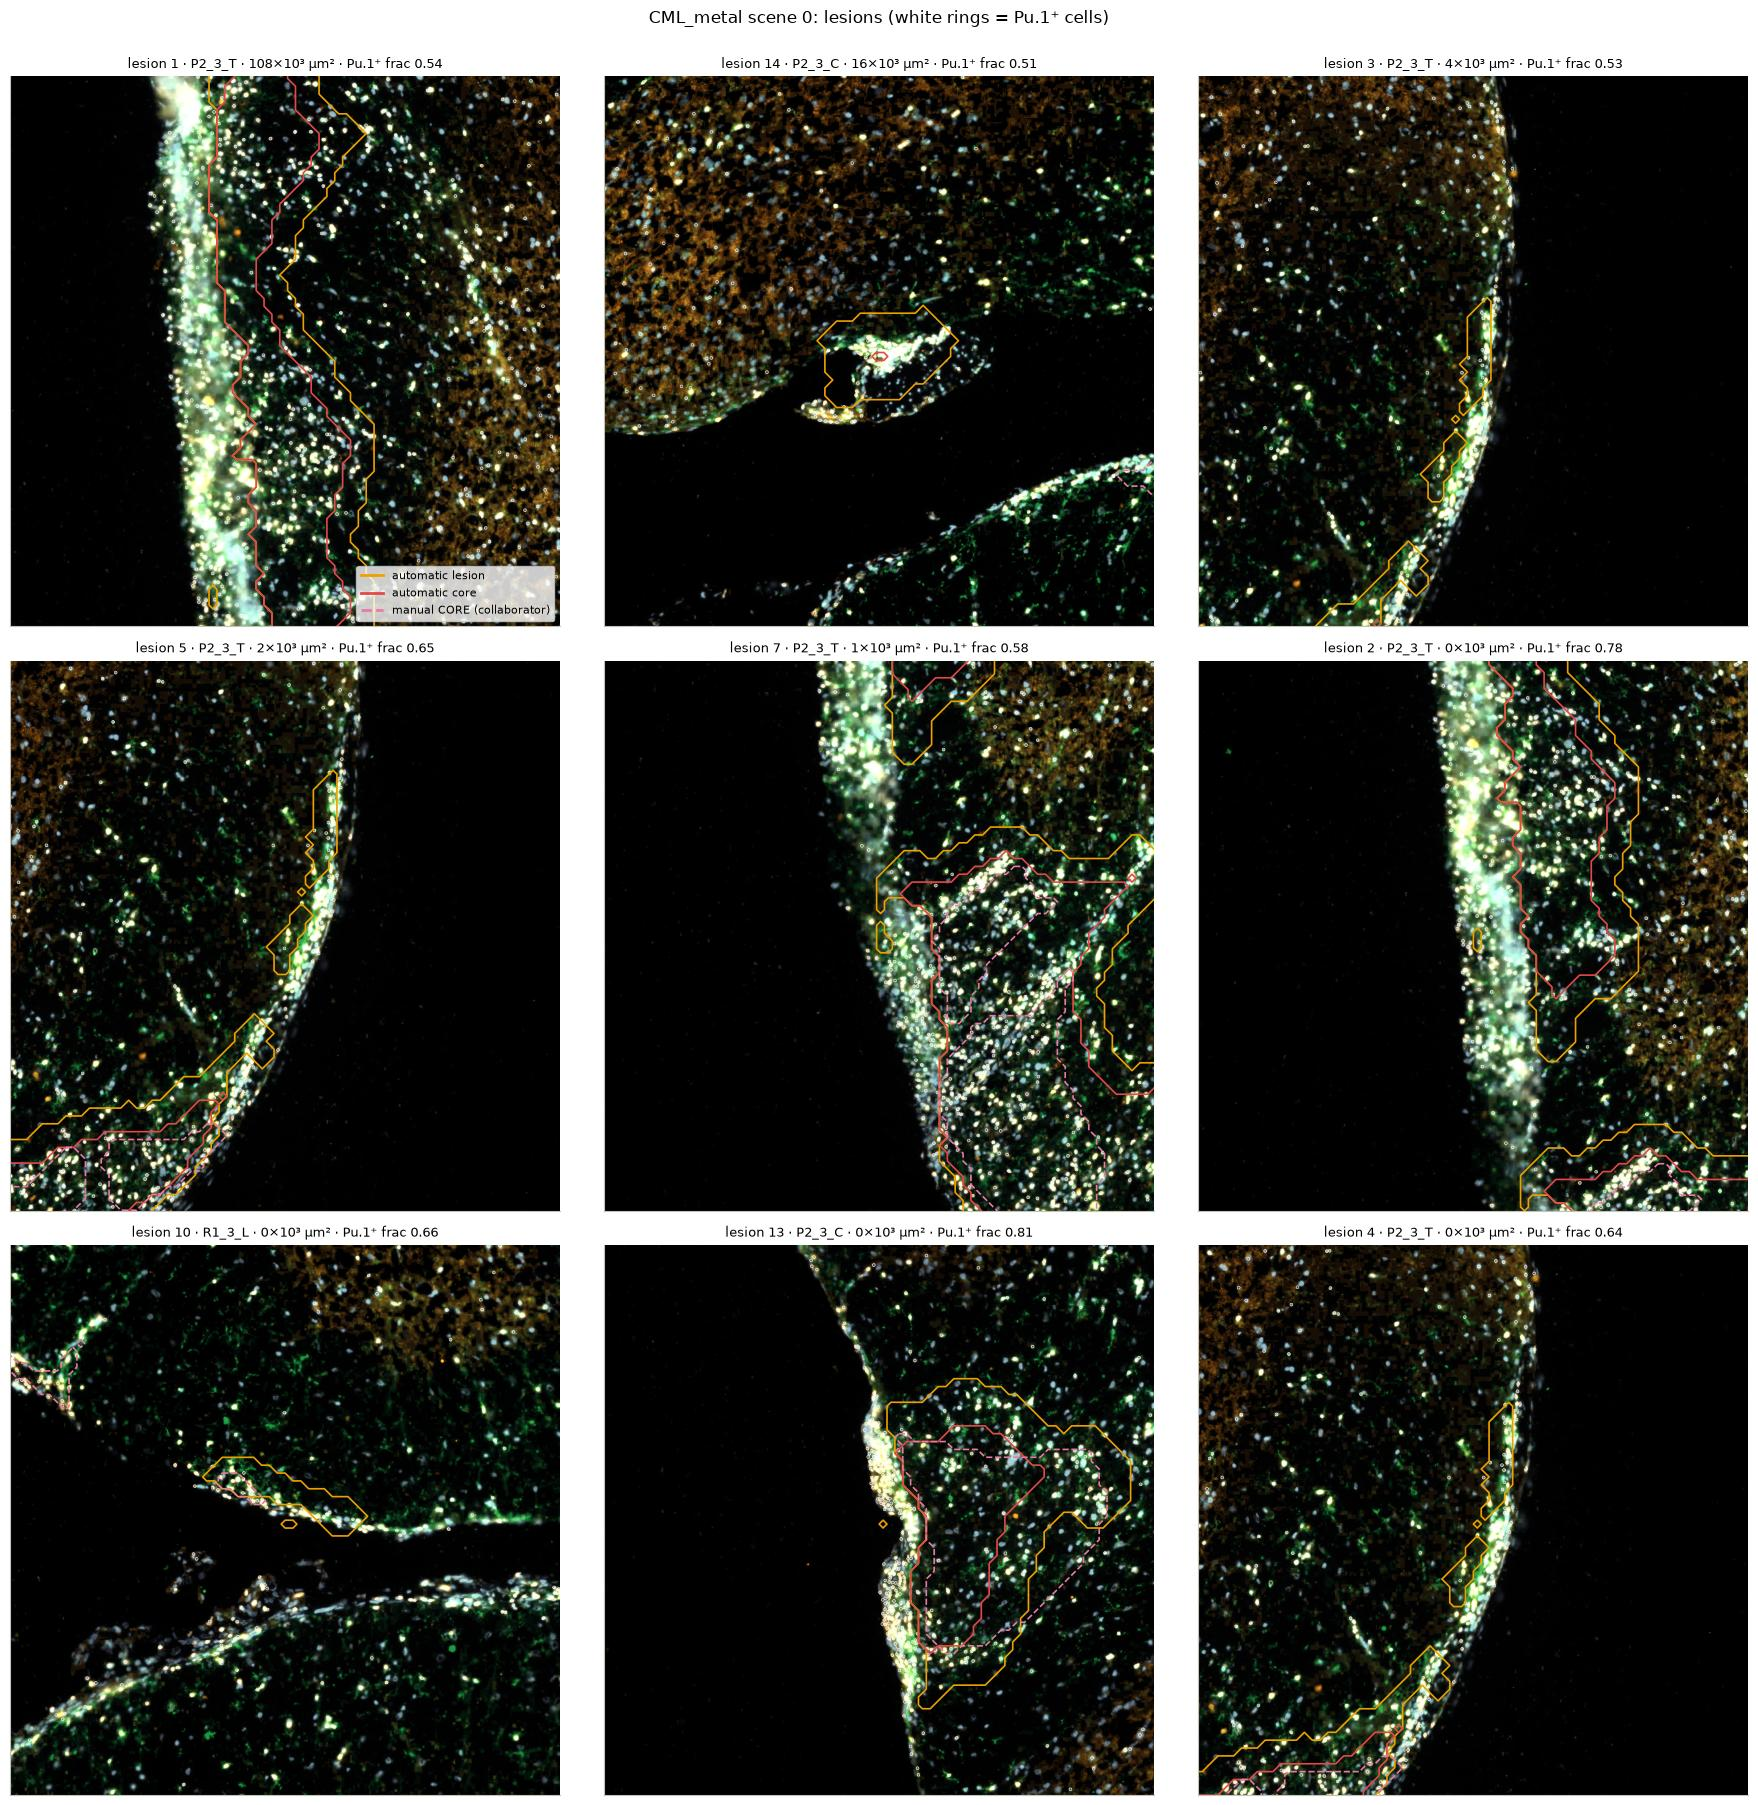

### CML_metal scene 1: 18 automatic lesion(s) without a manual core (0.14 mm²)

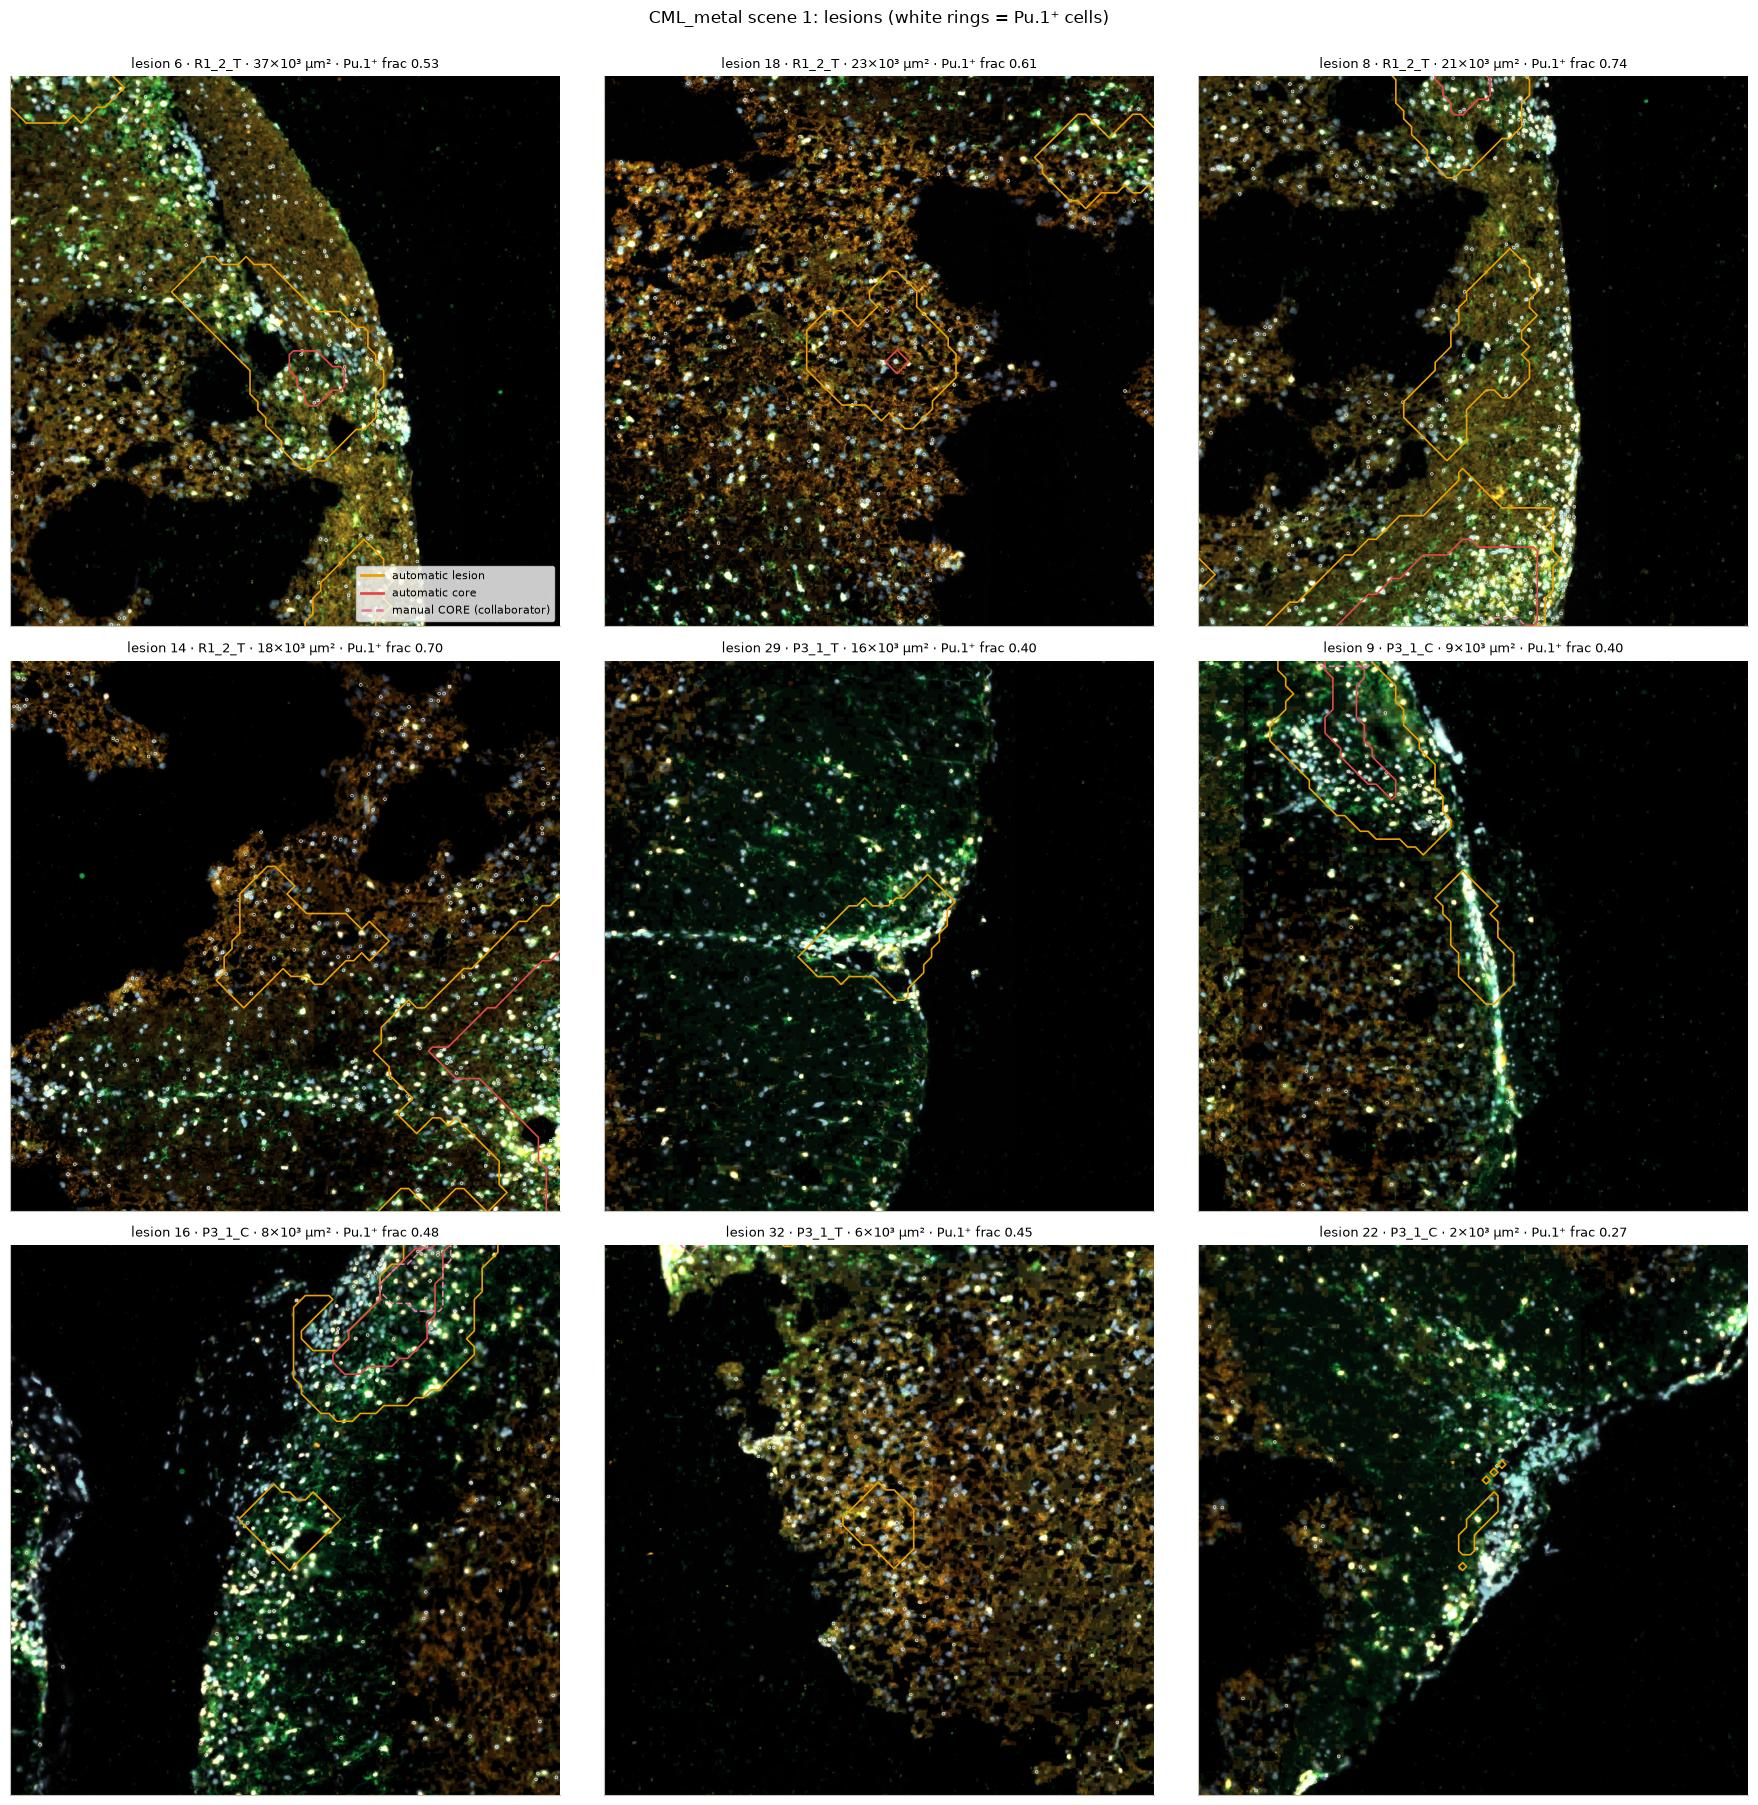

In [7]:
for r in runs:
    v = pd.read_csv(r.dir / "validation_manual_cores.csv")
    touched = set()
    for ids in v.auto_lesion_ids.astype(str):
        touched |= {int(x) for x in ids.strip("[]").split(",") if x.strip()}
    extra = r.lesions[~r.lesions.lesion_id.isin(touched)]
    display(Markdown(f"### {r.name}: {len(extra)} automatic lesion(s) without a manual core ({extra.area_um2.sum()/1e6:.2f} mm²)"))
    if len(extra):
        fig = R.lesion_gallery(r, lesion_ids=extra.lesion_id.tolist(), max_n=9)
        plt.show()

## Cell-level confusion: manual annotation × automatic zone

In [8]:
for r in runs:
    display(Markdown(f"### {r.name}"))
    display(pd.read_csv(r.dir / "validation_cell_confusion.csv", index_col=0))

### CML_1 scene 0

,distal,peri,rim,core,deep,meninges
manual_annotation,,,,,,
GM,7011,0,0,0,0,5
WM,3123,0,0,0,0,164
core,233,305,811,5275,54,137
none,15321,5699,2927,3919,4604,7135
vbo,178,101,12,0,30,0


### CML_2_rescan scene 0

,distal,peri,rim,core,deep,meninges
manual_annotation,,,,,,
GM,8791,0,0,0,0,5
WM,5510,0,0,0,0,439
core,0,994,3367,3892,25,91
none,12863,6903,3575,514,4415,8377
vbo,190,80,0,0,64,0


### CML_metal scene 0

,distal,peri,rim,core,deep,meninges
manual_annotation,,,,,,
GM,5341,0,0,0,0,0
WM,2045,0,0,0,0,191
core,266,218,824,2436,45,61
none,18633,4481,2317,1891,4481,7265
vbo,121,0,0,0,11,0


### CML_metal scene 1

,distal,peri,rim,core,deep,meninges
manual_annotation,,,,,,
GM,6214,0,0,0,0,20
WM,2354,0,0,0,0,178
core,55,132,861,1766,0,59
none,14205,5121,3749,2464,3212,10469
vbo,76,24,0,0,18,3
